#### Multiple linear Regression is a statistical technique used to model the relationship between a dependent variable and two or more independent variables. It extends simple linear regression by allowing for multiple predictors,   ####

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## 1. Data Preparation
We define our features (X) like experience and GPA, and our target variable (y) which is Salary. We'll visualize these relationships to see if they look linear.

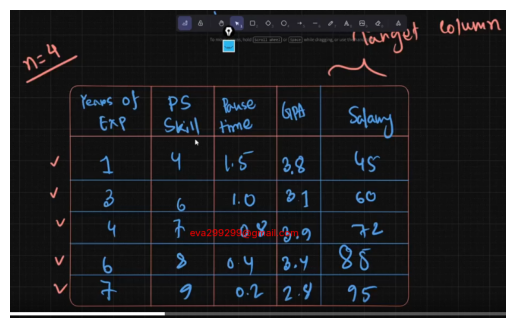

In [2]:
#code for attaching a picture
from PIL import Image
img = Image.open("multiple.png")
plt.imshow(img)
plt.axis('off')  
plt.show()

In [3]:
X = np.array([      # features coulum  (2D) like years of experience , PC skill, Pause time , GPA , 
    [1,4, 1.5, 3.8],
    [3,6, 1.0, 3.1],
    [4,7, 0.8, 3.9],
    [5,8, 0.4, 3.4],
    [7,9, 0.2, 2.8]
]) 
 
y= np.array([45.9 ,  76.55,  92.35, 107.9 , 128. ]) # target ccolumn like salary

Text(0.5, 1.0, 'Years of Experience vs Salary')

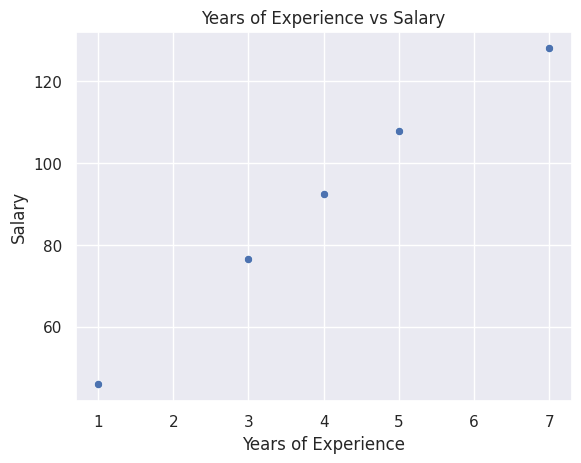

In [4]:
sns.scatterplot(x=X[:,0:1].ravel(), y= y)  # sliceing
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Years of Experience vs Salary')

Text(0.5, 1.0, 'PC Skill vs Salary')

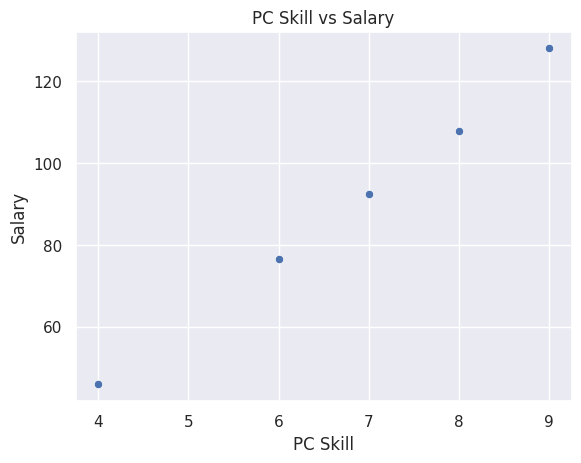

In [5]:
sns.scatterplot(x=X[:,1:2].ravel(), y= y)  
plt.xlabel('PC Skill')
plt.ylabel('Salary')
plt.title('PC Skill vs Salary')

Text(0.5, 1.0, 'Pause Time vs Salary')

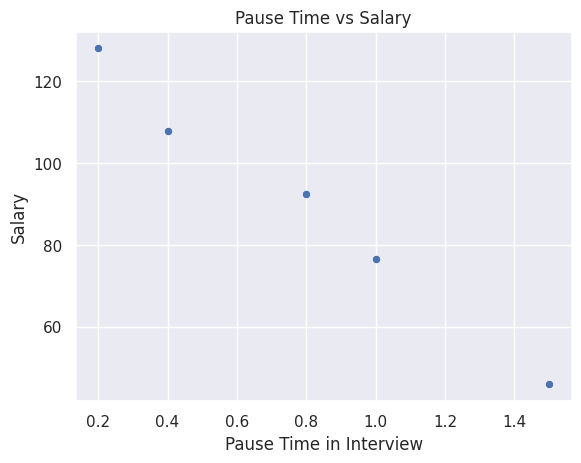

In [6]:
sns.scatterplot(x=X[:,2:3].ravel(), y= y)  
plt.xlabel('Pause Time in Interview')
plt.ylabel('Salary')
plt.title('Pause Time vs Salary')

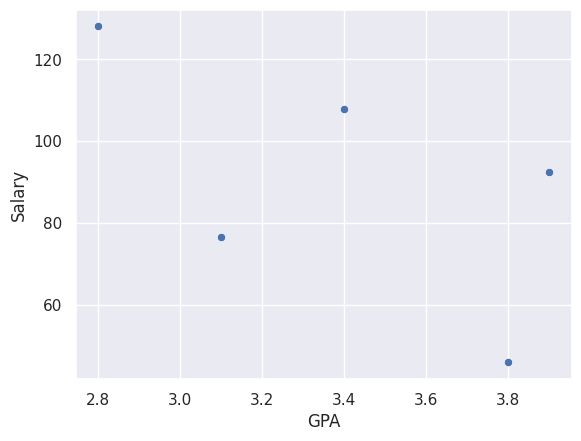

In [7]:
sns.scatterplot(x=X[:,3:].ravel(), y=y)
plt.xlabel("GPA")
plt.ylabel("Salary")
plt.show()

## 2. Manual Implementation
To understand how the model 'learns', we define three key components:

previously  y=wx+b for simple regression 

for multiple linear regression  y=w1x1 + w2x2 + ... + wnxn + b

1. **Prediction Function**: Calculates $f(x) = w_1x_1 + ... + w_nx_n + b$
2. **Cost Function**: Measures how far off our predictions are (Mean Squared Error).
3. **Gradient Descent**: The optimizer that adjusts weights ($w$) and bias ($b$) to minimize the cost.

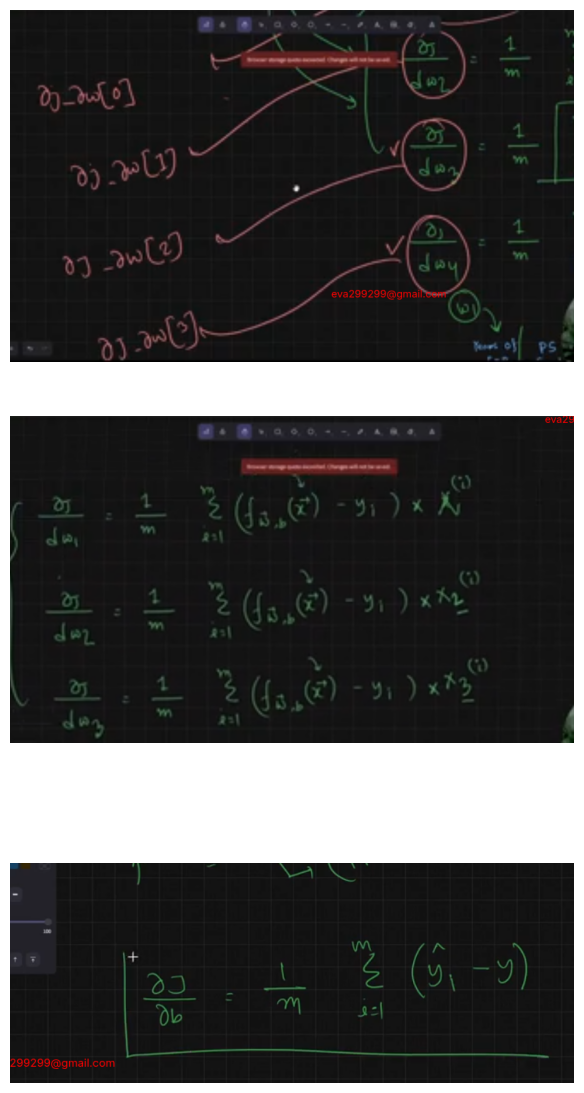

In [8]:
ig, axes = plt.subplots(3, 1, figsize=(6, 12))

for ax, image_path in zip(axes, ['formula.png', 'formula2.png', 'formula4.png', ]):
    ax.imshow(plt.imread(image_path))
    ax.axis('off')

plt.tight_layout()

### Make Prediction  ###

In [9]:
def make_prediction(X, W , b) :
    
   m= X.shape[0] # no of rows / employees
    
   pred_list = np.zeros(m)  #[0. 0. 0. 0. 0.] , predict salary for all employeee
   
    # X[0] = [1,4, 1.5, 3.8]  # features of employee 1
    # W = [w1, w2, w3, w4]  # weights for each feature
    
   for i in range(m) :
        
        pred_list[i] = np.dot(W,X[i]) +b #   w1*x1 + w2*x2 + w3*x3 + w4*x4 + b
        # print(f'Prediction  salary for employee {i+1} : {pred_list[i]}')
        
   return pred_list       
 

In [10]:
# X.shape()  # (5, 4) 5 employees and 4 features

n= X.shape[1] # no of coulum / features = 4

w_init= np .zeros(n)  # [0. 0. 0. 0.]  initial weights for each feature 1D array of n size 
b_init = 1.0

prediction_salary =make_prediction(X, w_init, b_init)
#print(f'Prediction salaries for all employees : {prediction_salary}')


#### Calculat cost  

In [11]:
def calculate_cost(X,y , W, b) :
    
    m = X.shape[0] # num of employee
    cost =0.0
    
    prediction_list = make_prediction(X,W,b)  #  1D list 
    
    error = prediction_list - y 
    # print(f'Error for each employee : {error}') 
    error_square = error**2
    cost = np.sum(error_square) 

    cost = cost/(2*m) # average cost 
     
    return cost 
    

In [12]:
w_init = np.ones(n) # [1. 1. 1. 1. 1.] weight for each feature  (4 features), 1D array 
b_init = 1.0   

calculated_cost = calculate_cost(X, y, w_init, b_init)
print(f'Calculated Cost : {calculated_cost}')


Calculated Cost : 3060.2095


In [13]:
def calculate_gradient(X, y,W,b) :
    
    m= X.shape[0] # no of employee 
    
    n =X.shape[1]  # no of feature 
    
    dj_dw = np.zeros((n,)) ## weigts for each feature , 4
    dj_db = 0.0 
    
    for i in range(m) :
        
        pred_list = np.dot(W,X[i]) +b
        error = pred_list - y[i]
        dj_db = dj_db +  error  # see image 
        
        for j in range(n) :
            
            dj_dw[j] = dj_dw[j] + error* X[i][j]  #  dj_dw[j] [ each feature's weight ] = multipleing error ( from formula)
                                                  # with corresponding  feature x[i][j] cell   ,for alll 4 features 
                                                              
    return dj_dw/m , dj_db/m      #   calculating average weight   
  

    

In [14]:
w_init = np.ones(n)
b_init =1.0 
print(f': dj_dw/m , dj_db/m for weights and bias =1 : f{calculate_gradient(X, y , w_init , b_init )} ')


: dj_dw/m , dj_db/m for weights and bias =1 : f(array([-346.21 , -547.09 ,  -46.502, -245.77 ]), np.float64(-74.16)) 


In [15]:
def gradient_descent(X, y, W, b, max_iter, alpha=0.01):
    
    cost_memo = []
    iteration = []
    
    for i in range(max_iter):
        
        dj_dw, dj_db = calculate_gradient(X, y, W, b)
         
         # here lets say  w= [1 , 1,1,1] and  dj_dw =[11,2,2,2]_ , so updating all the weights (4)
        W = W  - alpha * dj_dw
        b = b - alpha * dj_db
        
        cost = calculate_cost(X,y, W, b)
        cost_memo.append(cost)
        iteration.append(i)
        
        if i % 100 == 0:
          print(f"Iteration {i}: Cost {cost:0.4f},dj_dw: {dj_dw} ,dj_db : {dj_db} w: {W}, b: {b:0.4f}")

    return W, b, cost_memo, iteration

### Training the Model
We initialize our weights to zero and run the gradient descent loop for many iterations to find the optimal values.

In [16]:
W_init = np.zeros((n,))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, W=W_init, b=b_init, max_iter=100000)

Iteration 0: Cost 188.4458,dj_dw: [-416.09  -660.91   -57.608 -299.43 ] ,dj_db : -90.14 w: [4.1609  6.6091  0.57608 2.9943 ], b: 0.9014
Iteration 100: Cost 0.1977,dj_dw: [-0.28972633 -0.05290958  0.24653403  0.43027154] ,dj_db : 0.08612436152810546 w: [ 6.8215041   8.3071171  -0.38008643  1.775159  ], b: 0.7104
Iteration 200: Cost 0.1303,dj_dw: [ 0.02982799 -0.05138487  0.04097921  0.06083368] ,dj_db : 0.007027042739051126 w: [ 6.88604616  8.35924356 -0.48209566  1.60468101], b: 0.6799
Iteration 300: Cost 0.1229,dj_dw: [ 0.05097646 -0.04994653  0.0258774   0.03389236] ,dj_db : 0.001434162447482379 w: [ 6.84103994  8.40989801 -0.51257454  1.56262078], b: 0.6769
Iteration 400: Cost 0.1162,dj_dw: [ 0.05111217 -0.04855146  0.02422668  0.0311383 ] ,dj_db : 0.0010265453320016603 w: [ 6.7896808   8.45913669 -0.53741432  1.53048588], b: 0.6757
Iteration 500: Cost 0.1098,dj_dw: [ 0.04980317 -0.04719556  0.0235398   0.03011513] ,dj_db : 0.0009845325017138861 w: [ 6.7392106   8.50700022 -0.561278

In [17]:
print (w_final)
print (b_final)

[ 4.9736024  10.14304775 -1.56445471  0.47744225]
0.8695947679498179


### Making prediction ###

In [18]:
X_test=  [2,10, 1.5, 3.8] # 2 years of experience , 10 PC skill , 1.5 pause time and 3.8 GPA 
                          # now whats his salary 

prediction_salary = np.dot(w_final, X_test) + b_final  # W = [ 4.9736024  10.14304775 -1.56445471  0.47744225]

print("Predicted Salary:", prediction_salary)  


Predicted Salary: 111.71487549666952


# Linear Regression using scikit learn

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

In [20]:
model = LinearRegression()

model.fit(X,y)  # train/ learning phase

weights = model.coef_  # w1,w2,w3,w4
bias = model.intercept_  

print(f'Weights : {weights} , Bias : {bias}')

Weights : [ 5.  10.  -2.   0.5] , Bias : 2.000000000000142


### SGD Regressor
The SGDRegressor implements Stochastic Gradient Descent. It's particularly useful for very large datasets where the standard LinearRegression might be too slow.

In [31]:
model2= SGDRegressor(penalty =None , max_iter=10000000, learning_rate='constant')

model2.fit(X,y)

weihgts= model2.coef_
bias = model2.intercept_

print(f'Weights : {weihgts} , Bias : {bias}')

Weights : [ 5.86187438  9.28405335 -1.08524762  1.06359849] , Bias : [0.60863735]
